In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("../../data/emi_prediction_dataset_cleaned.csv")
df.shape

(398455, 31)

In [3]:
X = df.drop(['emi_eligibility', 'max_monthly_emi'], axis=1)
y = df['emi_eligibility']

In [4]:
cat_cols = X.select_dtypes(include=['object']).columns
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)
X.head()

,age,monthly_salary,years_of_employment,monthly_rent,family_size,dependents,school_fees,college_fees,travel_expenses,groceries_utilities,...,company_type_Mid-size,company_type_Small,company_type_Startup,house_type_Own,house_type_Rented,existing_loans_Yes,emi_scenario_Education EMI,emi_scenario_Home Appliances EMI,emi_scenario_Personal Loan EMI,emi_scenario_Vehicle EMI
0,38.0,82600.0,0.9,20000.0,3,2,0.0,0.0,7200.0,19500.0,...,True,False,False,False,True,True,False,False,True,False
1,38.0,21500.0,7.0,0.0,2,1,5100.0,0.0,1400.0,5400.0,...,False,False,False,False,False,True,False,False,False,False
2,38.0,86100.0,5.8,0.0,4,3,0.0,0.0,10200.0,19400.0,...,False,False,True,True,False,False,True,False,False,False
3,58.0,66800.0,2.2,0.0,5,4,11400.0,0.0,6200.0,11900.0,...,True,False,False,True,False,False,False,False,False,True
4,48.0,57300.0,3.4,0.0,4,3,9400.0,21300.0,3600.0,16200.0,...,True,False,False,False,False,False,False,True,False,False


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [6]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [ ]:
log_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

log_model.fit(X_train, y_train)

In [10]:
y_pred_train = log_model.predict(X_train)
y_prob_train = log_model.predict_proba(X_train)
roc_auc = roc_auc_score(y_train, y_prob_train, multi_class="ovr")

print("Accuracy:", accuracy_score(y_train, y_pred_train))
print("\nClassification Report:\n", classification_report(y_train, y_pred_train))
print("\nConfusion Matrix:\n", confusion_matrix(y_train, y_pred_train))
print("ROC AUC Score:", roc_auc)

Accuracy: 0.8040901732943494

Classification Report:
               precision    recall  f1-score   support

    Eligible       0.87      0.75      0.81     59058
   High_Risk       0.16      0.73      0.26     13891
Not_Eligible       0.99      0.82      0.90    245815

    accuracy                           0.80    318764
   macro avg       0.67      0.77      0.66    318764
weighted avg       0.93      0.80      0.85    318764


Confusion Matrix:
 [[ 44549  13277   1232]
 [  2668  10086   1137]
 [  3730  40405 201680]]
ROC AUC Score: 0.9362454789584511


In [ ]:
y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)
roc_auc = roc_auc_score(y_test, y_prob, multi_class="ovr")


print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC AUC Score:", roc_auc)

Accuracy: 0.8022612340163883

Classification Report:
               precision    recall  f1-score   support

    Eligible       0.87      0.74      0.80     14764
   High_Risk       0.16      0.72      0.26      3473
Not_Eligible       0.99      0.82      0.90     61454

    accuracy                           0.80     79691
   macro avg       0.67      0.76      0.65     79691
weighted avg       0.93      0.80      0.85     79691


Confusion Matrix:
 [[10985  3465   314]
 [  694  2490   289]
 [  933 10063 50458]]
ROC AUC Score: 0.9354846234690132


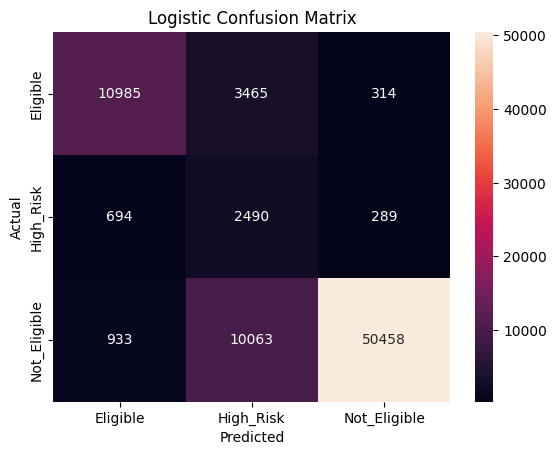

In [9]:
plt.figure()
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', xticklabels=log_model.classes_, yticklabels=log_model.classes_)
plt.title("Logistic Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()